# Upstream Network Analysis

This notebook demonstrates HMS basin network topology analysis using reproducible example-project folders.

The first section lists HMS-ready eBFE sources and checks the local Spring Creek eBFE delivery supplied for this review. The eBFE extraction API is available through `HmsExamples.extract_ebfe_project()`, but this notebook does not launch eBFE downloads because those source archives can be several gigabytes.

The current HMS-bearing eBFE deliveries are aggregate hydrology models with one subbasin and no routing network, and the Spring Creek delivery is RAS-only in this local workspace. The executable upstream network demonstration therefore uses the standard HMS `tenk` sample project in a notebook-scoped example workspace.

## What You'll Learn

1. Listing HMS-ready eBFE sources
2. Checking a local eBFE delivery for HMS inputs before using it in HMS examples
3. Verifying whether a basin file has enough topology for upstream analysis
4. Building reverse network lookup tables
5. Finding all upstream elements for a target
6. Calculating contributing drainage area
7. Exporting GIS layers for spatial verification


In [1]:
# pip install "hms-commander[dss,gis]" geopandas matplotlib


## Setup


In [2]:
import sys
from pathlib import Path

cwd = Path.cwd()
repo_root = cwd if (cwd / "hms_commander").exists() else cwd.parent
if (repo_root / "hms_commander").exists() and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from hms_commander import HmsBasin, HmsGeo, HmsExamples, __version__

import logging

logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("hms_commander").setLevel(logging.WARNING)


def display_path(path, base=None):
    path = Path(path)
    base = Path.cwd() if base is None else Path(base)
    try:
        return path.resolve().relative_to(base.resolve()).as_posix()
    except Exception:
        return path.name


pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

NOTEBOOK_ID = "015"
example_root = Path.cwd() / "example_projects"
workspace = example_root / f"upstream_network_{NOTEBOOK_ID}"
workspace.mkdir(parents=True, exist_ok=True)

print(f"hms-commander v{__version__}")
print(f"Notebook workspace: {display_path(workspace)}")
print(f"Example root: {display_path(example_root)}")

hms-commander v0.3.1
Notebook workspace: example_projects/upstream_network_015
Example root: example_projects


## Helper Functions


In [3]:
def summarize_basin(path: Path) -> dict:
    subbasins = HmsBasin.get_subbasins(path)
    junctions = HmsBasin.get_junctions(path)
    reaches = HmsBasin.get_reaches(path)
    diversions = HmsBasin.get_diversions(path)
    reservoirs = HmsBasin.get_reservoirs(path)
    sinks = HmsBasin.get_sinks(path)
    network = HmsBasin.get_upstream_network(path)
    return {
        "path": path,
        "Basin": path.name,
        "Subbasins": len(subbasins),
        "Junctions": len(junctions),
        "Reaches": len(reaches),
        "Diversions": len(diversions),
        "Reservoirs": len(reservoirs),
        "Sinks": len(sinks),
        "Network_Targets": len(network),
        "Network_Links": sum(len(values) for values in network.values()),
        "Total_Area_sqmi": float(subbasins["area"].sum()) if "area" in subbasins else 0.0,
    }


def summarize_project(project_dir: Path) -> pd.DataFrame:
    basin_files = sorted(project_dir.glob("*.basin"))
    if not basin_files:
        raise FileNotFoundError(f"No .basin files found in {project_dir}")
    return pd.DataFrame(summarize_basin(path) for path in basin_files)


## eBFE HMS Sources

`HmsExamples` exposes the HMS-ready portion of ras-commander's eBFE catalog when ras-commander is available. Listing the catalog is safe for automated validation. Extracting an eBFE delivery is intentionally left as an explicit follow-up step because the source archives are large and may require local cache paths.


In [4]:
ebfe_sources = HmsExamples.list_ebfe_projects()
display(ebfe_sources)

if ebfe_sources.empty:
    print("No HMS-validated eBFE sources are exposed by the installed ras-commander build.")
else:
    keys = ", ".join(ebfe_sources["key"].astype(str).tolist())
    print(f"HMS-validated eBFE source keys: {keys}")
    print("Use HmsExamples.extract_ebfe_project(...) explicitly when the corresponding eBFE source cache is available.")


,key,study_area,huc8,ras_version,hms_validated,notes
0,north-galveston-bay,NorthGalvestonBay_12040203,12040203,5.0.7,True,Compound HMS plus nested 2D RAS delivery.
1,lake-maurepas,LakeMaurepas_08070204,08070204,5.0.7,True,Louisiana 2D eBFE model archive.


HMS-validated eBFE source keys: north-galveston-bay, lake-maurepas
Use HmsExamples.extract_ebfe_project(...) explicitly when the corresponding eBFE source cache is available.


## Spring eBFE Catalog Check

Use `HmsExamples` to inspect eBFE availability instead of probing a workstation-specific folder. The executable network demonstration still uses the packaged `tenk` HMS sample because the Spring Creek eBFE delivery is not exposed as an HMS-validated source in the shared catalog.

In [5]:
try:
    ebfe_catalog_all = HmsExamples.list_ebfe_projects(hms_only=False)
    spring_mask = ebfe_catalog_all.apply(
        lambda row: "spring" in " ".join(str(value).lower() for value in row.values)
        or "12040102" in " ".join(str(value) for value in row.values),
        axis=1,
    )
    spring_status = ebfe_catalog_all.loc[spring_mask].copy()
except Exception as exc:
    spring_status = pd.DataFrame([{
        "key": "SpringCreek_12040102",
        "hms_validated": False,
        "notes": f"eBFE catalog unavailable: {exc}",
    }])

if spring_status.empty:
    spring_status = pd.DataFrame([{
        "key": "SpringCreek_12040102",
        "hms_validated": False,
        "notes": "Not present as an HMS-validated eBFE source in HmsExamples catalog.",
    }])

display(spring_status)

if not bool(spring_status.get("hms_validated", pd.Series([False])).fillna(False).any()):
    print("Spring Creek is not available as an HMS-validated eBFE source; continuing with packaged HMS sample.")
else:
    print("Spring Creek is available through HmsExamples.extract_ebfe_project(...) for HMS-specific follow-up analysis.")

,key,study_area,huc8,ras_version,hms_validated,notes
0,spring-creek,SpringCreek_12040102,12040102,5.0.7,False,Single 2D unsteady model with nested final arc...
4,spring-river,SpringRiver_11010010,11010010,6.1,False,Distinct Spring HUC model archive. Uses Spring...


Spring Creek is not available as an HMS-validated eBFE source; continuing with packaged HMS sample.


## Network Demonstration Project

The validated eBFE HMS sources listed above are useful HMS loading examples but are aggregate one-subbasin models. The local Spring Creek eBFE folder is present for this review but is RAS-only and does not contain HMS basin inputs. For the executable upstream-network workflow, use HMS sample project `tenk`; it has a small but complete routing network and is extracted to `example_projects/tenk_015`.


In [6]:
network_project_dir = HmsExamples.extract_project(
    "tenk",
    output_path=example_root,
    suffix=NOTEBOOK_ID,
    overwrite=False,
)

network_summary = summarize_project(network_project_dir).sort_values(
    ["Network_Links", "Subbasins"],
    ascending=False,
).reset_index(drop=True)

basin_path = Path(network_summary.loc[0, "path"])
geo_files = sorted(network_project_dir.glob("*.geo"))
map_files = sorted(network_project_dir.glob("*.map"))
geo_path = geo_files[0] if geo_files else None
map_path = map_files[0] if map_files else None

print(f"Network project folder: {display_path(network_project_dir)}")
print(f"Selected basin: {basin_path.name}")
print(f"Geometry sidecar: {geo_path.name if geo_path else 'not included in sample'}")
print(f"Map sidecar: {map_path.name if map_path else 'not included in sample'}")
display(network_summary.drop(columns=["path"]))


Network project folder: example_projects/tenk_015
Selected basin: Tenk_1.basin
Geometry sidecar: not included in sample
Map sidecar: not included in sample


,Basin,Subbasins,Junctions,Reaches,Diversions,Reservoirs,Sinks,Network_Targets,Network_Links,Total_Area_sqmi
0,Tenk_1.basin,4,5,5,0,0,0,10,13,1611.0


## 1. Extract HMS Element Types

A complete topology pass starts by reading subbasins, junctions, reaches, diversions, reservoirs, and sinks. This public sample does not contain diversions, but the same calls handle diversion-bearing projects.


In [7]:
subbasins = HmsBasin.get_subbasins(basin_path)
junctions = HmsBasin.get_junctions(basin_path)
reaches = HmsBasin.get_reaches(basin_path)
diversions = HmsBasin.get_diversions(basin_path)
reservoirs = HmsBasin.get_reservoirs(basin_path)
sinks = HmsBasin.get_sinks(basin_path)

print(f"Subbasins:  {len(subbasins)}")
print(f"Junctions:  {len(junctions)}")
print(f"Reaches:    {len(reaches)}")
print(f"Diversions: {len(diversions)}")
print(f"Reservoirs: {len(reservoirs)}")
print(f"Sinks:      {len(sinks)}")

if diversions.empty:
    print("No diversions found in this basin.")
else:
    display(diversions[["name", "downstream", "divert_to", "canvas_x", "canvas_y"]])


Subbasins:  4
Junctions:  5
Reaches:    5
Diversions: 0
Reservoirs: 0
Sinks:      0
No diversions found in this basin.


## 2. Build Reverse Network Lookup

HMS basin files store downstream connections. `HmsBasin.get_upstream_network()` inverts those relationships into a lookup of what flows into each target element.


In [8]:
upstream_network = HmsBasin.get_upstream_network(basin_path)

print(f"Targets with upstream connections: {len(upstream_network)}")
print(f"Total upstream links: {sum(len(values) for values in upstream_network.values())}")

for candidate, direct in list(upstream_network.items())[:10]:
    print(f"{candidate}: {len(direct)} direct upstream element(s)")


Targets with upstream connections: 10
Total upstream links: 13
Watts: 1 direct upstream element(s)
Tahlequah: 2 direct upstream element(s)
Eldon: 1 direct upstream element(s)
Tenkiller: 2 direct upstream element(s)
R-1: 1 direct upstream element(s)
R-3: 1 direct upstream element(s)
R-4: 1 direct upstream element(s)
R-5: 1 direct upstream element(s)
R-2: 1 direct upstream element(s)
conf: 2 direct upstream element(s)


## 3. Select a Target

Pick the element with the largest contributing area and at least one upstream subbasin.


In [9]:
target_rows = []
for candidate in sorted(upstream_network):
    upstream_candidate = HmsBasin.get_upstream_elements(basin_path, candidate)
    if not upstream_candidate["subbasins"]:
        continue

    area_sqmi = HmsBasin.get_contributing_area(basin_path, candidate)
    target_rows.append({
        "Target": candidate,
        "Area_sqmi": area_sqmi,
        "Upstream_Subbasins": len(upstream_candidate["subbasins"]),
        "Upstream_Junctions": len(upstream_candidate["junctions"]),
        "Upstream_Reaches": len(upstream_candidate["reaches"]),
        "Upstream_Diversions": len(upstream_candidate["diversions"]),
    })

if not target_rows:
    raise RuntimeError("No target with upstream subbasins was found.")

targets_df = pd.DataFrame(target_rows).sort_values(
    ["Area_sqmi", "Upstream_Subbasins"],
    ascending=False,
).reset_index(drop=True)

target = targets_df.loc[0, "Target"]
print(f"Selected target: {target}")
display(targets_df.head(10))


Selected target: Tenkiller


,Target,Area_sqmi,Upstream_Subbasins,Upstream_Junctions,Upstream_Reaches,Upstream_Diversions
0,Tenkiller,1611.0,4,4,0,0
1,R-5,1266.0,3,4,0,0
2,conf,1266.0,3,3,0,0
3,R-3,959.0,2,2,0,0
4,Tahlequah,959.0,2,1,0,0
5,R-1,635.0,1,1,0,0
6,R-2,635.0,1,1,0,0
7,Watts,635.0,1,0,0,0
8,Eldon,307.0,1,0,0,0
9,R-4,307.0,1,1,0,0


## 4. Find All Upstream Elements

`HmsBasin.get_upstream_elements()` recursively traverses the reverse network and returns upstream elements grouped by HMS element type.


In [10]:
upstream = HmsBasin.get_upstream_elements(basin_path, target)

print(f"=== Upstream Elements for {target} ===")
print(f"Subbasins:  {len(upstream['subbasins'])}")
print(f"Junctions:  {len(upstream['junctions'])}")
print(f"Reaches:    {len(upstream['reaches'])}")
print(f"Diversions: {len(upstream['diversions'])}")
print(f"Total:      {sum(len(values) for values in upstream.values())}")

print("\nUpstream subbasins:")
for name in upstream["subbasins"]:
    print(f"  - {name}")


=== Upstream Elements for Tenkiller ===
Subbasins:  4
Junctions:  4
Reaches:    0
Diversions: 0
Total:      8

Upstream subbasins:
  - 127
  - 85
  - 86
  - 113


## 5. Calculate Contributing Drainage Area

`HmsBasin.get_contributing_area()` combines upstream traversal with subbasin area summation.


In [11]:
area = HmsBasin.get_contributing_area(basin_path, target)
total_area = float(subbasins["area"].sum()) if "area" in subbasins else 0.0

print(f"=== Contributing Drainage Area for {target} ===")
print(f"Target contributing area: {area:.2f} sq mi")
print(f"Total basin subbasin area: {total_area:.2f} sq mi")
print(f"Upstream subbasins: {len(upstream['subbasins'])} of {len(subbasins)}")
print(f"Upstream diversions: {len(upstream['diversions'])} of {len(diversions)}")


=== Contributing Drainage Area for Tenkiller ===
Target contributing area: 1611.00 sq mi
Total basin subbasin area: 1611.00 sq mi
Upstream subbasins: 4 of 4
Upstream diversions: 0 of 0


## 6. Extract GIS Layers

The Tenk sample uses HMS schematic coordinates rather than a real-world projection. `EPSG:3857` is used here only as a convenient plotting CRS for the exported GeoJSON layers.


In [12]:
output_dir = workspace / "outputs" / basin_path.stem
output_dir.mkdir(parents=True, exist_ok=True)

outputs = HmsGeo.extract_all_gis(
    basin_path=basin_path,
    geo_path=geo_path if geo_path and geo_path.exists() else None,
    map_path=map_path if map_path and map_path.exists() else None,
    output_dir=output_dir,
    crs_epsg="EPSG:3857",
    include_diversions=True,
)

print("=== Extracted GeoJSON Files ===")
for key, path in outputs.items():
    if path.exists():
        gdf = gpd.read_file(path)
        print(f"{key:15} -> {path.name:30} ({len(gdf)} features)")


=== Extracted GeoJSON Files ===
subbasins       -> hms_subbasins.geojson          (4 features)
junctions       -> hms_junctions.geojson          (5 features)
reaches         -> hms_reaches.geojson            (5 features)


## 7. Visualize the Upstream Network


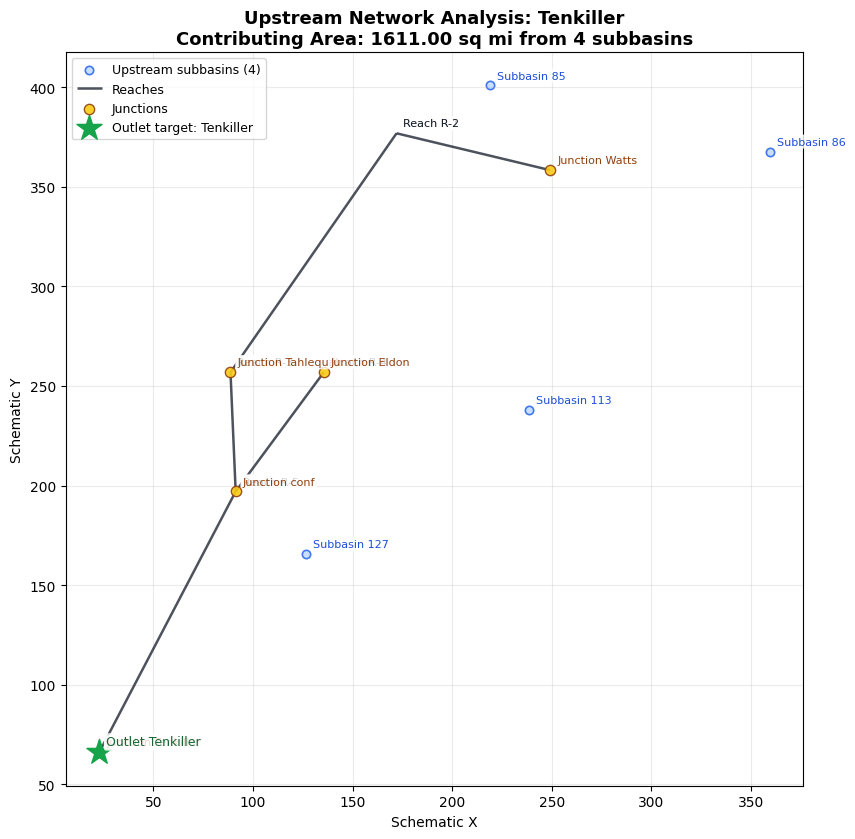

Map saved to: example_projects/upstream_network_015/outputs/Tenk_1/upstream_network_Tenkiller.png


In [13]:
subbasins_gdf = gpd.read_file(outputs["subbasins"])
junctions_gdf = gpd.read_file(outputs["junctions"])
reaches_gdf = gpd.read_file(outputs["reaches"]) if "reaches" in outputs else None
diversions_gdf = gpd.read_file(outputs["diversions"]) if "diversions" in outputs else None

upstream_names = set(upstream["subbasins"])
subbasins_gdf["is_upstream"] = subbasins_gdf["name"].isin(upstream_names)

fig, ax = plt.subplots(figsize=(11, 8.5))

other_subbasins = subbasins_gdf[~subbasins_gdf["is_upstream"]]
upstream_subbasins = subbasins_gdf[subbasins_gdf["is_upstream"]]

if not other_subbasins.empty:
    other_subbasins.plot(ax=ax, color="#e5e7eb", edgecolor="#9ca3af", linewidth=0.8, alpha=0.65, label="Other subbasins")
if not upstream_subbasins.empty:
    upstream_subbasins.plot(ax=ax, color="#bfdbfe", edgecolor="#2563eb", linewidth=1.2, alpha=0.85, label=f"Upstream subbasins ({len(upstream_names)})")

if reaches_gdf is not None and not reaches_gdf.empty:
    reaches_gdf.plot(ax=ax, color="#111827", linewidth=1.8, alpha=0.75, zorder=2, label="Reaches")

if not junctions_gdf.empty:
    junctions_gdf.plot(ax=ax, color="#facc15", edgecolor="#92400e", markersize=55, alpha=0.9, zorder=3, label="Junctions")

if diversions_gdf is not None and not diversions_gdf.empty:
    diversions_gdf.plot(ax=ax, color="#dc2626", marker="D", markersize=80, alpha=0.85, zorder=4, label=f"Diversions ({len(diversions_gdf)})")

target_junction = junctions_gdf[junctions_gdf["name"].str.lower() == str(target).lower()] if "name" in junctions_gdf else junctions_gdf.iloc[0:0]
if not target_junction.empty:
    target_junction.plot(ax=ax, color="#16a34a", marker="*", markersize=360, zorder=5, label=f"Outlet target: {target}")


def label_geometry(gdf, label_column="name", color="#111827", fontsize=8, prefix=""):
    if gdf is None or gdf.empty or label_column not in gdf:
        return
    for _, row in gdf.iterrows():
        point = row.geometry.representative_point()
        label = f"{prefix}{row[label_column]}"
        ax.annotate(
            label,
            (point.x, point.y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=fontsize,
            color=color,
            bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": "none", "alpha": 0.82},
            zorder=8,
        )

label_geometry(upstream_subbasins, color="#1d4ed8", fontsize=8, prefix="Subbasin ")
label_geometry(other_subbasins, color="#4b5563", fontsize=7, prefix="Subbasin ")
label_geometry(reaches_gdf, color="#111827", fontsize=8, prefix="Reach ")
label_geometry(junctions_gdf, color="#92400e", fontsize=8, prefix="Junction ")
if not target_junction.empty:
    label_geometry(target_junction, color="#166534", fontsize=9, prefix="Outlet ")
if diversions_gdf is not None and not diversions_gdf.empty:
    label_geometry(diversions_gdf, color="#991b1b", fontsize=8, prefix="Diversion ")

ax.set_title(
    f"Upstream Network Analysis: {target}\n"
    f"Contributing Area: {area:.2f} sq mi from {len(upstream_names)} subbasins",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Schematic X")
ax.set_ylabel("Schematic Y")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
figure_path = output_dir / f"upstream_network_{target}.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Map saved to: {display_path(figure_path)}")

## 8. Compare Candidate Targets


In [14]:
print("=== Top Candidate Targets by Contributing Area ===")
display(targets_df)

print("=== Summary Statistics ===")
print(f"Targets analyzed: {len(targets_df)}")
print(f"Area range: {targets_df['Area_sqmi'].min():.2f} - {targets_df['Area_sqmi'].max():.2f} sq mi")
print(f"Mean area: {targets_df['Area_sqmi'].mean():.2f} sq mi")
print(f"Median area: {targets_df['Area_sqmi'].median():.2f} sq mi")
print(f"Targets with upstream diversions: {(targets_df['Upstream_Diversions'] > 0).sum()}")


=== Top Candidate Targets by Contributing Area ===


,Target,Area_sqmi,Upstream_Subbasins,Upstream_Junctions,Upstream_Reaches,Upstream_Diversions
0,Tenkiller,1611.0,4,4,0,0
1,R-5,1266.0,3,4,0,0
2,conf,1266.0,3,3,0,0
3,R-3,959.0,2,2,0,0
4,Tahlequah,959.0,2,1,0,0
5,R-1,635.0,1,1,0,0
6,R-2,635.0,1,1,0,0
7,Watts,635.0,1,0,0,0
8,Eldon,307.0,1,0,0,0
9,R-4,307.0,1,1,0,0


=== Summary Statistics ===
Targets analyzed: 10
Area range: 307.00 - 1611.00 sq mi
Mean area: 858.00 sq mi
Median area: 797.00 sq mi
Targets with upstream diversions: 0


## Key Takeaways

1. `HmsExamples.list_ebfe_projects()` exposes HMS-validated eBFE source keys without downloading large archives.
2. `HmsExamples.extract_ebfe_project()` remains available for explicit HMS-bearing eBFE extraction when the source cache is available.
3. Candidate local eBFE folders should be checked for HMS inputs before using them in HMS-specific examples.
4. Spring Creek eBFE is present in the local engineering workspace, but this delivery is RAS-only and has no HMS basin file.
5. The currently validated packaged eBFE HMS deliveries are aggregate one-subbasin models, so they are useful HMS examples but not useful upstream-network topology examples.
6. `HmsExamples.extract_project(..., suffix="015")` gives standard HMS examples the same collision-free notebook folder contract.
7. `get_upstream_network()`, `get_upstream_elements()`, and `get_contributing_area()` work on the selected network basin without hardcoded local paths.
8. `extract_all_gis(include_diversions=True)` supports spatial verification and will include diversion layers when the basin contains diversions.
